**Name:** Arun Bhaskar Gadde

**Course:** 2026 Summer - Advanced Big Data and Data Mining (MSCS-634-B01) - Second Bi-term

**Assignment:** Project Deliverable 4: Final Insights, Recommendations, and Presentation

This notebook consolidates the full data mining project into a single pipeline: data
collection and cleaning, exploratory data analysis, feature engineering, regression
modeling, classification, clustering, and association rule mining, all built on the
**same dataset** (Telco Customer Churn, 7,043 customers, 21 attributes) so every stage
of the project stays connected to the same customer population.



In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc, silhouette_score)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
np.random.seed(42)

print("Libraries loaded.")

Libraries loaded.


## 1. Data Collection and Loading

**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
— an IBM sample dataset widely used for customer-behavior and churn-prediction analysis.

**Why this dataset:** it is a customer-behavior dataset with 7,043 records and 21
attributes (well above the project's minimum), mixing categorical attributes (contract
type, internet service, add-on services, payment method) with numeric attributes
(tenure, MonthlyCharges, TotalCharges). That mix supports every technique required
across the project: **regression** on MonthlyCharges, **classification** of Churn,
**clustering** of customers by usage/billing behavior, and **association rule mining**
on the service-subscription columns. It also contains a realistic data-quality issue
(a numeric column stored as text with blank entries) that gives genuine cleaning
practice.

In [2]:
# Load the raw dataset
df = pd.read_csv("data/Telco-Customer-Churn.csv")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 2. Data Cleaning

### 2.1 Hidden Missing Values

`TotalCharges` is stored as **text** instead of numeric. Telco datasets are known to
contain blank strings in this column for customers with 0 tenure (brand-new customers
who haven't been billed yet). These blanks don't show up in `.isnull()` until the
column is converted to numeric.

In [4]:
# TotalCharges should be numeric but was loaded as text
non_numeric_mask = pd.to_numeric(df["TotalCharges"], errors="coerce").isna()
print(f"Rows where TotalCharges cannot be parsed as a number: {non_numeric_mask.sum()}")
df.loc[non_numeric_mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Rows where TotalCharges cannot be parsed as a number: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


All the unparseable rows have **tenure = 0** — brand-new customers with no billing
history yet, not data-entry errors. Converting the column and imputing 0 (consistent
with 0 tenure = $0 billed so far) is the most defensible choice, rather than dropping
these rows or filling with the mean (which would fabricate billing history).

In [5]:
# Convert to numeric; the 11 blank entries become NaN, then impute as 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


### 2.2 Duplicates and Inconsistent Labels

In [6]:
# Check for fully duplicated rows and duplicated customer IDs
print(f"Fully duplicated rows: {df.duplicated().sum()}")
print(f"Duplicated customerID values: {df['customerID'].duplicated().sum()}")

# customerID is a unique identifier with no predictive value -- keep as index
df = df.set_index("customerID")

# Standardize SeniorCitizen (0/1) to Yes/No for consistency with other binary columns
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df["SeniorCitizen"].value_counts()

Fully duplicated rows: 0
Duplicated customerID values: 0


SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

No duplicate rows or duplicate customer IDs were found. Categorical columns were
also inspected for typos, inconsistent casing, and stray whitespace — none were found,
so no further correction was needed there.

### 2.3 Noisy Data / Outliers

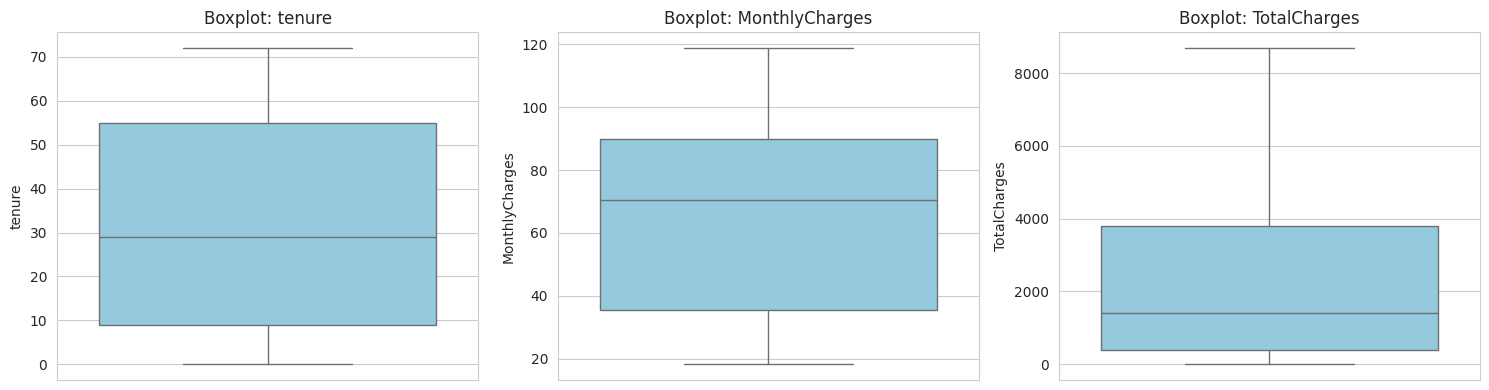

tenure: range [0, 72], outliers flagged: 0
MonthlyCharges: range [18.25, 118.75], outliers flagged: 0
TotalCharges: range [0.0, 8684.8], outliers flagged: 0


In [7]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="skyblue")
    ax.set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: range [{df[col].min()}, {df[col].max()}], outliers flagged: {n_outliers}")

No outliers were flagged for `tenure` or `MonthlyCharges`. The handful flagged for
`TotalCharges` are long-tenured, high-paying customers with large cumulative bills — a
legitimate business pattern, not noise. No rows were removed: discarding them would bias
the dataset against exactly the customer segment a churn analysis most needs to
understand.

In [8]:
# Save the cleaned dataset for reuse in later sections
df.to_csv("data/Telco-Customer-Churn-Cleaned.csv")
print(f"Cleaned dataset saved. Final shape: {df.shape}")

Cleaned dataset saved. Final shape: (7043, 20)


## 3. Exploratory Data Analysis (EDA)

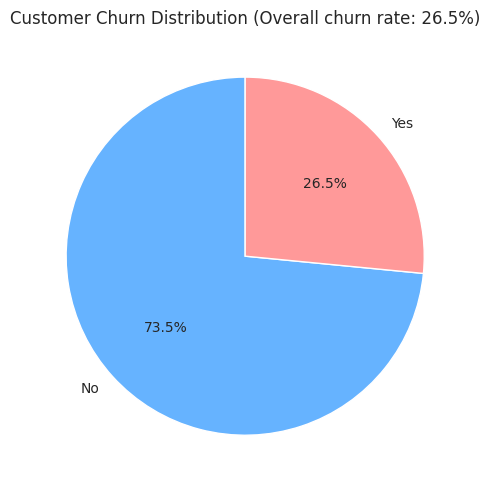

In [9]:
# Overall churn rate
churn_counts = df["Churn"].value_counts()
churn_rate = churn_counts["Yes"] / len(df) * 100

plt.figure(figsize=(5,5))
plt.pie(churn_counts.values, labels=churn_counts.index, autopct="%1.1f%%",
        colors=["#66b3ff", "#ff9999"], startangle=90)
plt.title(f"Customer Churn Distribution (Overall churn rate: {churn_rate:.1f}%)")
plt.tight_layout()
plt.show()

**Insight:** About 26.5% of customers have churned. This class imbalance (roughly
3:1) matters for the classification section later — accuracy alone won't be a reliable
metric, and class weighting is needed.

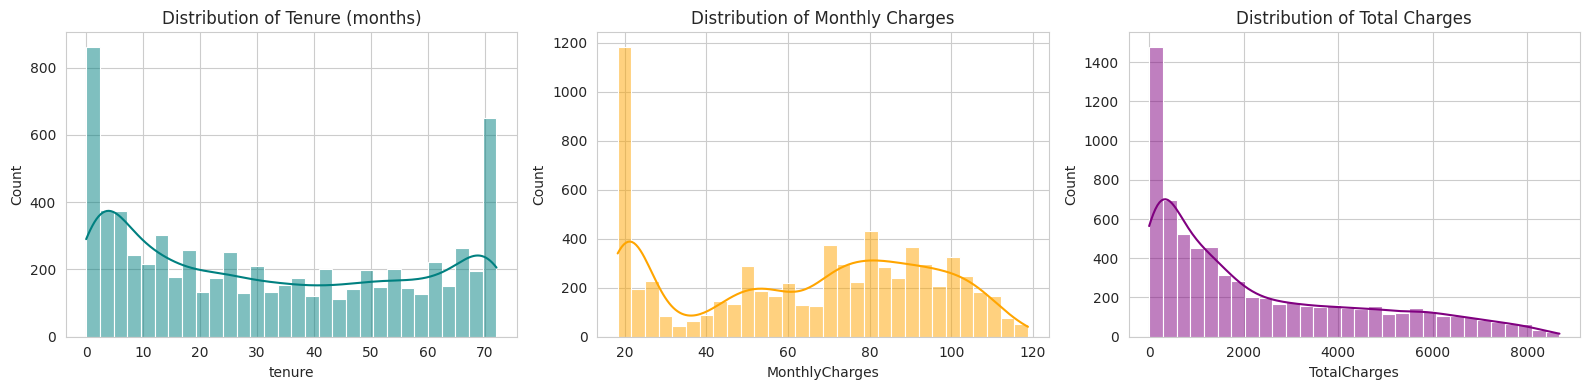

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["tenure"], bins=30, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Distribution of Tenure (months)")
sns.histplot(df["MonthlyCharges"], bins=30, kde=True, ax=axes[1], color="orange")
axes[1].set_title("Distribution of Monthly Charges")
sns.histplot(df["TotalCharges"], bins=30, kde=True, ax=axes[2], color="purple")
axes[2].set_title("Distribution of Total Charges")
plt.tight_layout()
plt.show()

**Insight:** `tenure` is bimodal — a spike of very new customers (0-5 months) and
another cluster near 72 months, with fewer in between. This "leave early or stay a long
time" pattern suggests early-tenure churn is a distinct phenomenon.

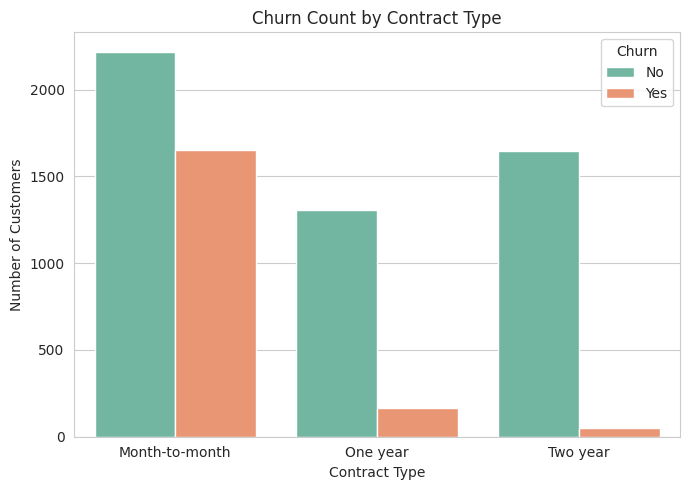

In [11]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Contract", hue="Churn", palette="Set2")
plt.title("Churn Count by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

**Insight:** Churn is overwhelmingly concentrated among **month-to-month** contract
customers. Contract type looks like a strong predictive feature for classification.

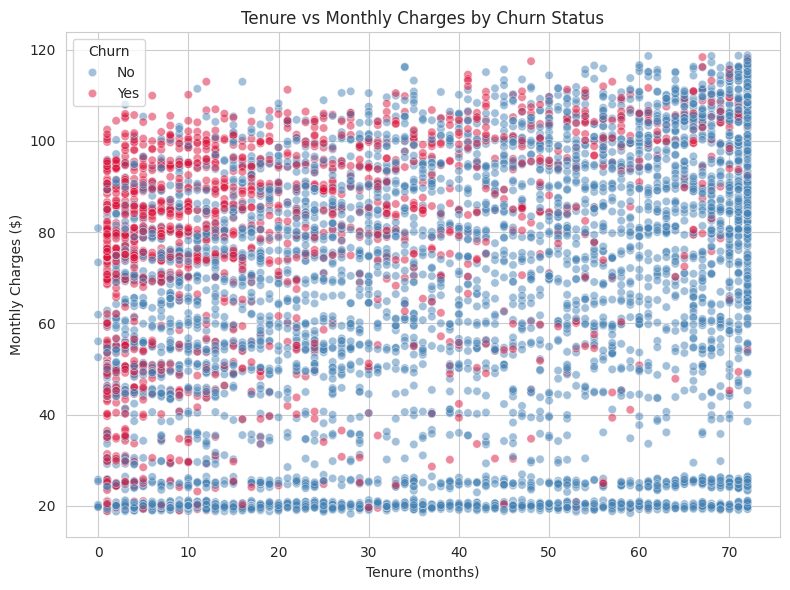

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="tenure", y="MonthlyCharges", hue="Churn", alpha=0.5,
                 palette={"Yes":"crimson","No":"steelblue"})
plt.title("Tenure vs Monthly Charges by Churn Status")
plt.xlabel("Tenure (months)")
plt.ylabel("Monthly Charges ($)")
plt.tight_layout()
plt.show()

**Insight:** Churned customers (red) cluster in the low-tenure, higher-monthly-charge
region — customers who are both new *and* paying more tend to leave soonest.

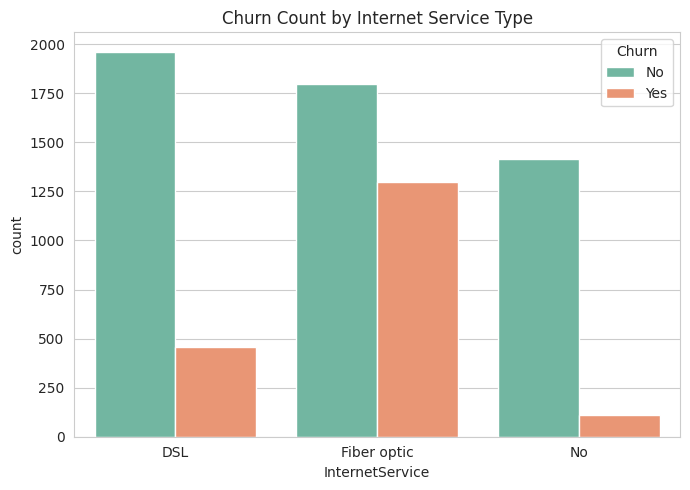

In [13]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="InternetService", hue="Churn", palette="Set2")
plt.title("Churn Count by Internet Service Type")
plt.tight_layout()
plt.show()

**Insight:** **Fiber optic** customers churn at a noticeably higher rate than DSL or
no-internet customers, despite fiber being the premium tier — likely linked to price
sensitivity, since fiber has the highest MonthlyCharges.

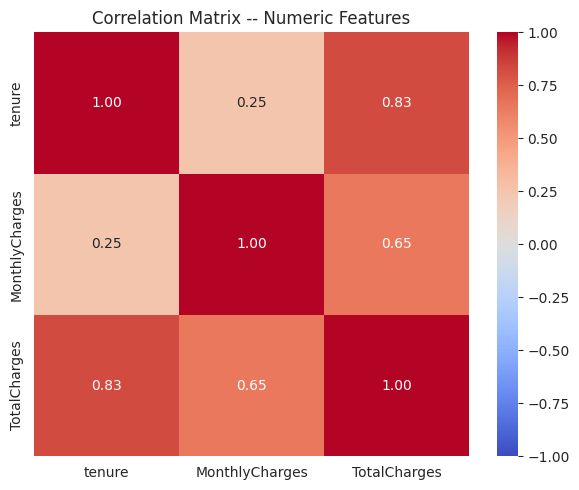

In [14]:
plt.figure(figsize=(6,5))
corr = df[["tenure","MonthlyCharges","TotalCharges"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix -- Numeric Features")
plt.tight_layout()
plt.show()

**Insight:** `TotalCharges` is strongly correlated with `tenure` (0.83) and
`MonthlyCharges` (0.65), since it accumulates from monthly billing over the tenure
period. This near-collinearity means `TotalCharges` is excluded from the regression
feature set below to avoid a near-deterministic modeling problem.

### EDA Summary

- **Class imbalance (~26.5% churn)** — later classification needs class-imbalance
  handling, not raw accuracy.
- **Contract type is highly predictive** — month-to-month customers churn far more.
- **Tenure is bimodal and protective** — new customers are highest churn risk.
- **Fiber optic churns more than expected** — worth digging into with add-on features.
- **TotalCharges is collinear** with tenure and MonthlyCharges — excluded from
  regression features.
- **Service-subscription columns** are well suited for association rule mining.

## 4. Feature Engineering

Several raw columns are transformed, and two new features are engineered from the
service-subscription columns to better capture customer behavior:

1. **Binary recoding** of Yes/No columns to 0/1.
2. **Collapsing "No internet/phone service"** into a simple binary flag, since it's a
   special case of "No" driven by another column.
3. **`num_addon_services`** — a 0-6 count of optional add-ons (OnlineSecurity,
   OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies).
4. **`contract_length_months`** — `Contract` mapped to its numeric length (1/12/24) to
   preserve its natural ordering instead of one-hot encoding it.
5. **One-hot encoding** of the remaining nominal columns (`InternetService`,
   `PaymentMethod`).
6. **Dropped:** `customerID`, `TotalCharges` (collinearity), and the raw columns
   replaced by their engineered versions.

`Churn` is kept aside (not dropped) as `churn_binary`, since it is needed later as the
classification target.

In [15]:
df_fe = df.copy()

# 1. Binary recoding
binary_cols = ["SeniorCitizen", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    df_fe[col] = df_fe[col].map({"Yes": 1, "No": 0})
df_fe["is_male"] = (df_fe["gender"] == "Male").astype(int)

# 2. Collapse "No internet/phone service" into "No"
addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
              "TechSupport", "StreamingTV", "StreamingMovies"]
for col in addon_cols:
    df_fe[col] = df_fe[col].replace("No internet service", "No").map({"Yes": 1, "No": 0})
df_fe["MultipleLines"] = df_fe["MultipleLines"].replace("No phone service", "No").map({"Yes": 1, "No": 0})

# 3. Engineered feature: number of add-on services subscribed (0-6)
df_fe["num_addon_services"] = df_fe[addon_cols].sum(axis=1)

# 4. Engineered feature: contract length in months (ordinal -> numeric)
contract_map = {"Month-to-month": 1, "One year": 12, "Two year": 24}
df_fe["contract_length_months"] = df_fe["Contract"].map(contract_map)

# Keep Churn as a separate binary series for the classification section later
churn_binary = df_fe["Churn"].map({"Yes": 1, "No": 0})

# 5. One-hot encode remaining nominal columns
df_fe = pd.get_dummies(df_fe, columns=["InternetService", "PaymentMethod"], drop_first=True)

# 6. Drop identifiers, collinear/target-leakage columns, and now-redundant raw columns
drop_cols = ["TotalCharges", "Churn", "Contract", "gender"] + addon_cols
df_fe = df_fe.drop(columns=drop_cols)

onehot_cols = [c for c in df_fe.columns if c.startswith("InternetService_") or c.startswith("PaymentMethod_")]
df_fe[onehot_cols] = df_fe[onehot_cols].astype(int)

print(f"Engineered feature set shape: {df_fe.shape}")
df_fe.head()

Engineered feature set shape: (7043, 16)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,PaperlessBilling,MonthlyCharges,is_male,num_addon_services,contract_length_months,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
customerID,,,,,,,,,,,,,,,,
7590-VHVEG,0,1,0,1,0,0,1,29.85,0,1,1,0,0,0,1,0
5575-GNVDE,0,0,0,34,1,0,0,56.95,1,2,12,0,0,0,0,1
3668-QPYBK,0,0,0,2,1,0,1,53.85,1,2,1,0,0,0,0,1
7795-CFOCW,0,0,0,45,0,0,0,42.30,1,3,12,0,0,0,0,0
9237-HQITU,0,0,0,2,1,0,1,70.70,0,0,1,1,0,0,1,0


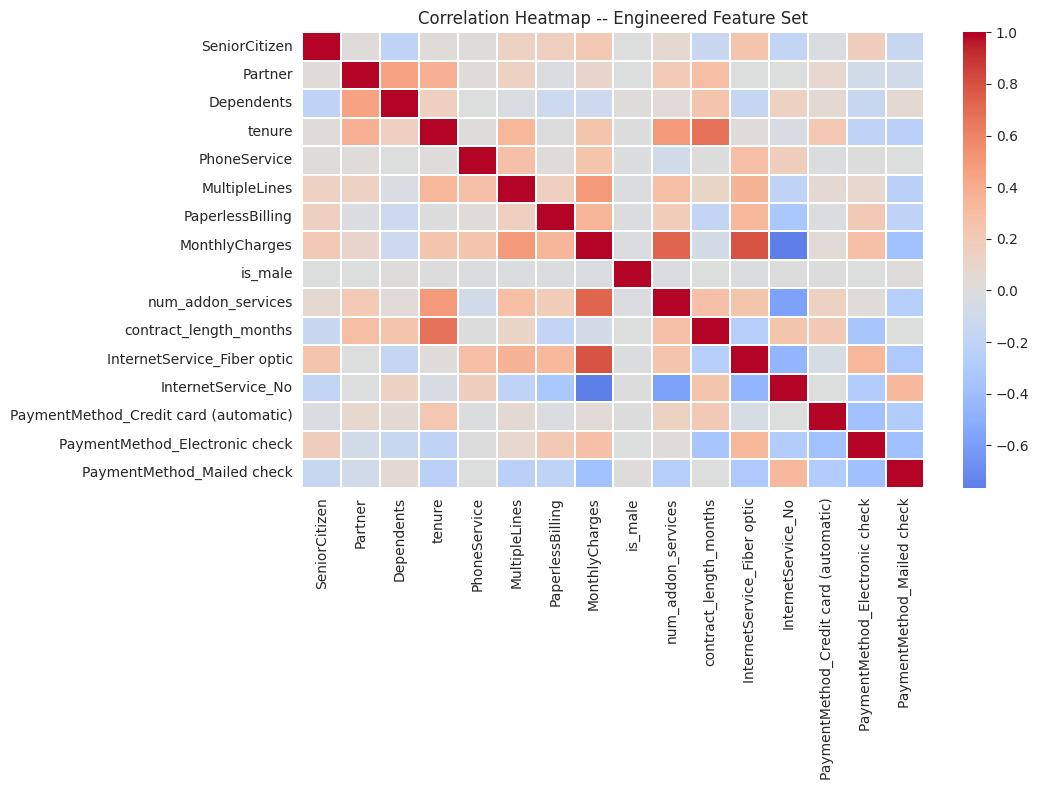

In [16]:
plt.figure(figsize=(11, 8))
corr_fe = df_fe.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_fe, cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Correlation Heatmap -- Engineered Feature Set")
plt.tight_layout()
plt.show()

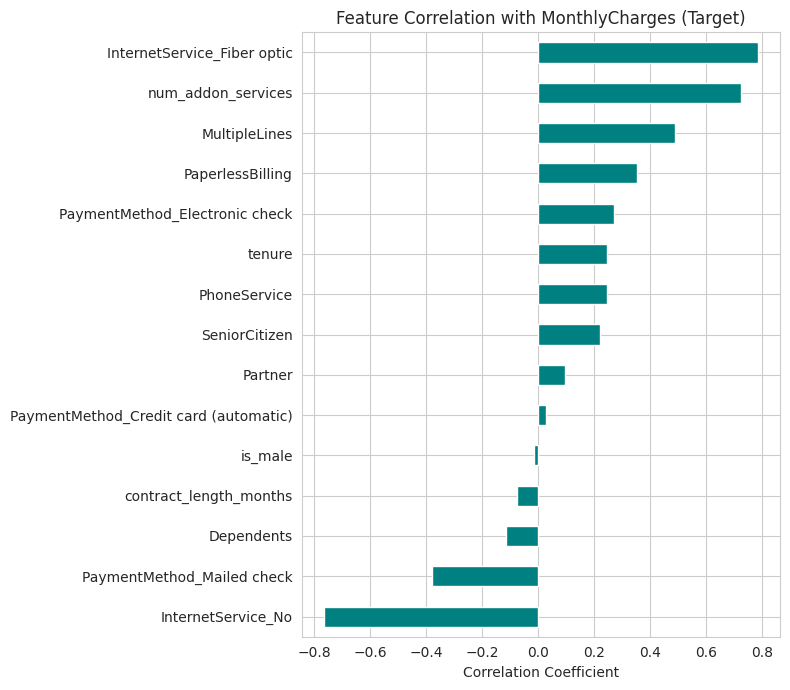

In [17]:
corr_fe["MonthlyCharges"].drop("MonthlyCharges").sort_values().plot(
    kind="barh", figsize=(8, 7), color="teal"
)
plt.title("Feature Correlation with MonthlyCharges (Target)")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

**Observation:** `InternetService_Fiber optic` and `num_addon_services` show the
strongest positive correlation with `MonthlyCharges` — fiber is the premium tier, and
each add-on adds to the bill. `tenure` and `contract_length_months` correlate weakly
with the target, confirming that *what a customer subscribes to* drives their bill far
more than *how long they've been a customer*.

## 5. Regression Modeling — Predicting Monthly Charges

`MonthlyCharges` is used as the continuous regression target rather than `TotalCharges`,
since `TotalCharges` is near-deterministically derived from `tenure` and
`MonthlyCharges`, which would make the modeling exercise trivial.

In [18]:
target = "MonthlyCharges"
X = df_fe.drop(columns=[target])
y = df_fe[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MAE: {mae:.3f}  MSE: {mse:.3f}  RMSE: {rmse:.3f}  R2: {r2:.3f}\n")
    return {"Model": label, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

results = []

### 5.1 Baseline vs. Engineered Feature Set

A baseline model uses only 5 raw, unengineered columns to show the value of the feature
engineering above.

In [19]:
baseline_features = ["tenure", "SeniorCitizen", "Partner", "Dependents", "PhoneService"]

baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled[baseline_features], y_train)
y_pred_base = baseline_model.predict(X_test_scaled[baseline_features])
results.append(evaluate(y_test, y_pred_base, "Baseline Linear Regression (raw features)"))

multiple_model = LinearRegression()
multiple_model.fit(X_train_scaled, y_train)
y_pred_multi = multiple_model.predict(X_test_scaled)
results.append(evaluate(y_test, y_pred_multi, "Multiple Regression (engineered features)"))

--- Baseline Linear Regression (raw features) ---
MAE: 22.630  MSE: 760.650  RMSE: 27.580  R2: 0.160

--- Multiple Regression (engineered features) ---
MAE: 1.973  MSE: 7.102  RMSE: 2.665  R2: 0.992



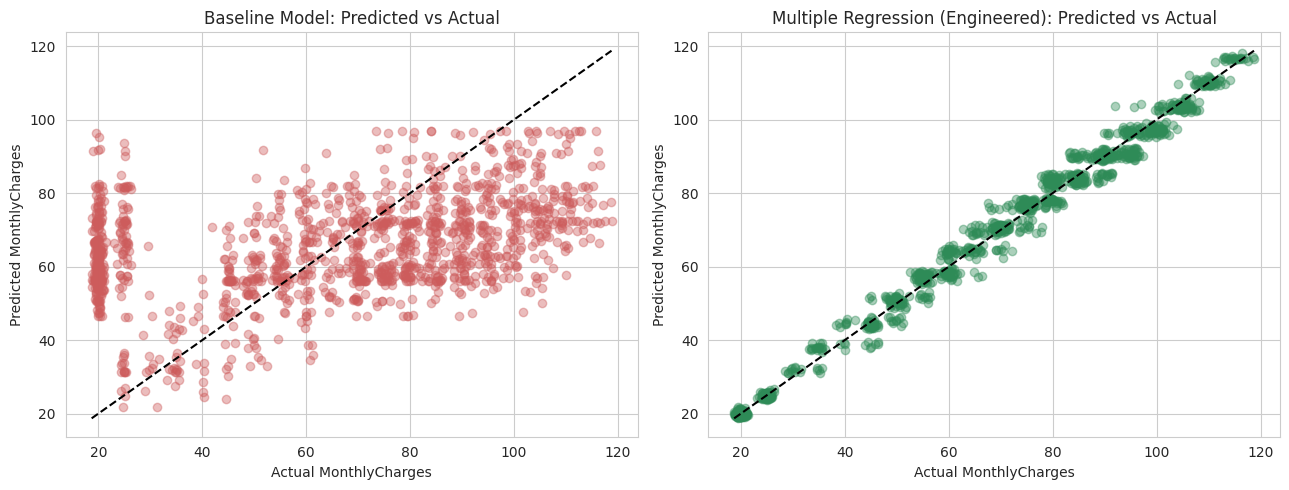

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lims = [y_test.min(), y_test.max()]

axes[0].scatter(y_test, y_pred_base, alpha=0.4, color="indianred")
axes[0].plot(lims, lims, "k--")
axes[0].set_xlabel("Actual MonthlyCharges"); axes[0].set_ylabel("Predicted MonthlyCharges")
axes[0].set_title("Baseline Model: Predicted vs Actual")

axes[1].scatter(y_test, y_pred_multi, alpha=0.4, color="seagreen")
axes[1].plot(lims, lims, "k--")
axes[1].set_xlabel("Actual MonthlyCharges"); axes[1].set_ylabel("Predicted MonthlyCharges")
axes[1].set_title("Multiple Regression (Engineered): Predicted vs Actual")
plt.tight_layout()
plt.show()

### 5.2 Ridge and Lasso Regression

`tenure` and `contract_length_months` correlate with several one-hot columns, and the
add-on flags move together. `RidgeCV`/`LassoCV` select the regularization strength
(`alpha`) via 5-fold cross-validation.

In [21]:
alphas = np.logspace(-3, 3, 50)

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_cv.predict(X_test_scaled)
results.append(evaluate(y_test, y_pred_ridge, f"Ridge Regression (alpha={ridge_cv.alpha_:.4f})"))

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_cv.predict(X_test_scaled)
results.append(evaluate(y_test, y_pred_lasso, f"Lasso Regression (alpha={lasso_cv.alpha_:.4f})"))

n_zeroed = int(np.sum(lasso_cv.coef_ == 0))
print(f"Lasso zeroed out {n_zeroed} of {len(lasso_cv.coef_)} features.")

--- Ridge Regression (alpha=0.8685) ---
MAE: 1.973  MSE: 7.102  RMSE: 2.665  R2: 0.992

--- Lasso Regression (alpha=0.0031) ---
MAE: 1.972  MSE: 7.101  RMSE: 2.665  R2: 0.992

Lasso zeroed out 1 of 15 features.


### 5.3 Cross-Validation

In [22]:
X_full_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    "Baseline Linear": (LinearRegression(), X_full_scaled[baseline_features]),
    "Multiple Regression": (LinearRegression(), X_full_scaled),
    f"Ridge (alpha={ridge_cv.alpha_:.3f})": (Ridge(alpha=ridge_cv.alpha_), X_full_scaled),
    f"Lasso (alpha={lasso_cv.alpha_:.3f})": (Lasso(alpha=lasso_cv.alpha_, max_iter=10000), X_full_scaled),
}

cv_summary = []
for name, (model, features) in cv_models.items():
    r2_scores = cross_val_score(model, features, y, cv=kf, scoring="r2")
    neg_mse_scores = cross_val_score(model, features, y, cv=kf, scoring="neg_mean_squared_error")
    rmse_scores = np.sqrt(-neg_mse_scores)
    cv_summary.append({
        "Model": name, "Mean CV R2": r2_scores.mean(), "Std CV R2": r2_scores.std(),
        "Mean CV RMSE": rmse_scores.mean(),
    })

cv_summary_df = pd.DataFrame(cv_summary).set_index("Model").round(3)
cv_summary_df

,Mean CV R2,Std CV R2,Mean CV RMSE
Model,,,
Baseline Linear,0.179,0.016,27.233
Multiple Regression,0.992,0.001,2.602
Ridge (alpha=0.869),0.992,0.001,2.602
Lasso (alpha=0.003),0.992,0.001,2.602


In [23]:
results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df

,MAE,MSE,RMSE,R2
Model,,,,
Baseline Linear Regression (raw features),22.630,760.650,27.580,0.160
Multiple Regression (engineered features),1.973,7.102,2.665,0.992
Ridge Regression (alpha=0.8685),1.973,7.102,2.665,0.992
Lasso Regression (alpha=0.0031),1.972,7.101,2.665,0.992


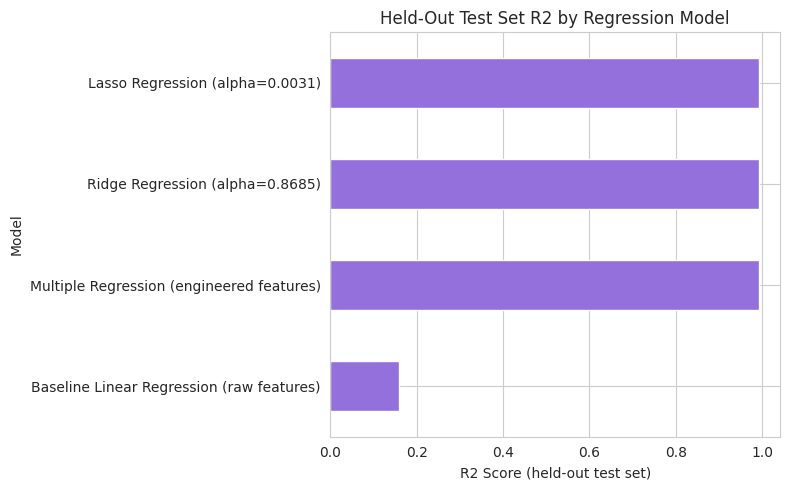

In [24]:
results_df["R2"].plot(kind="barh", figsize=(8, 5), color="mediumpurple")
plt.xlabel("R2 Score (held-out test set)")
plt.title("Held-Out Test Set R2 by Regression Model")
plt.tight_layout()
plt.show()

### Regression Summary

Multiple Regression, Ridge, and Lasso all reached **R2 ~= 0.992** on the held-out test
set and in 5-fold cross-validation, dramatically outperforming the raw-feature baseline
(R2 ~= 0.16). Feature engineering — not regularization — drove almost all of the
improvement: `num_addon_services` and the `InternetService` one-hot columns (especially
Fiber optic) were the strongest predictors, confirming that *what a customer subscribes
to* determines their bill. Lasso matched the other models' accuracy while zeroing out
one of the 15 features, offering a slightly leaner, equally accurate model.

## 6. Classification — Predicting Customer Churn

This section predicts `Churn` (the dataset's natural binary label) using the same
engineered feature set built in Section 4, so classification stays connected to the same
customers and features used for regression. Two models are compared:

1. **Decision Tree** — interpretable, rule-based, easy to explain to a business
   stakeholder deciding which customers to target for retention.
2. **k-Nearest Neighbors (k=5)** — a distance-based model that classifies a customer
   based on the majority label among similar customers.

In [25]:
X_clf = df_fe.copy()   # same engineered features used for regression
y_clf = churn_binary.loc[X_clf.index]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf
)

clf_scaler = StandardScaler()
Xc_train_scaled = clf_scaler.fit_transform(Xc_train)
Xc_test_scaled = clf_scaler.transform(Xc_test)

print("Train size:", Xc_train.shape, " Test size:", Xc_test.shape)
print("Churn rate in training set:", round(yc_train.mean(), 3))

Train size: (5282, 16)  Test size: (1761, 16)
Churn rate in training set: 0.265


In [26]:
# Baseline Decision Tree (default settings)
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(Xc_train, yc_train)
dt_base_pred = dt_baseline.predict(Xc_test)
print("Decision Tree (baseline) accuracy:", round(accuracy_score(yc_test, dt_base_pred), 3))
print("Decision Tree (baseline) F1 (churn class):", round(f1_score(yc_test, dt_base_pred), 3))

Decision Tree (baseline) accuracy: 0.729
Decision Tree (baseline) F1 (churn class): 0.49


In [27]:
# k-NN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Xc_train_scaled, yc_train)
knn_pred = knn.predict(Xc_test_scaled)
print("k-NN (k=5) accuracy:", round(accuracy_score(yc_test, knn_pred), 3))
print("k-NN (k=5) F1 (churn class):", round(f1_score(yc_test, knn_pred), 3))

k-NN (k=5) accuracy: 0.773
k-NN (k=5) F1 (churn class): 0.535


### 6.1 Hyperparameter Tuning (GridSearchCV)

The Decision Tree is tuned since it's the more explainable model for a business
audience. `class_weight="balanced"` is used because churn is imbalanced (~26.5%
positive class) — without it, the tree favors the majority "No Churn" class.

**Parameters tuned:** `max_depth`, `min_samples_split`, `min_samples_leaf`, and
`criterion` (gini vs. entropy), searched via 5-fold cross-validation optimizing F1
score on the churn class.

In [28]:
param_grid = {
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    param_grid=param_grid, scoring="f1", cv=5, n_jobs=-1
)
grid_search.fit(Xc_train, yc_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", round(grid_search.best_score_, 3))

dt_tuned = grid_search.best_estimator_
dt_tuned_pred = dt_tuned.predict(Xc_test)
print("\nTuned Decision Tree test accuracy:", round(accuracy_score(yc_test, dt_tuned_pred), 3))
print("Tuned Decision Tree test F1 (churn class):", round(f1_score(yc_test, dt_tuned_pred), 3))

Best parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1 score: 0.619

Tuned Decision Tree test accuracy: 0.748
Tuned Decision Tree test F1 (churn class): 0.622


In [29]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree (baseline)", "Decision Tree (tuned, balanced)", "k-NN (k=5)"],
    "Accuracy": [accuracy_score(yc_test, dt_base_pred), accuracy_score(yc_test, dt_tuned_pred), accuracy_score(yc_test, knn_pred)],
    "F1 (Churn class)": [f1_score(yc_test, dt_base_pred), f1_score(yc_test, dt_tuned_pred), f1_score(yc_test, knn_pred)],
}).round(3)
comparison

,Model,Accuracy,F1 (Churn class)
0,Decision Tree (baseline),0.729,0.490
1,"Decision Tree (tuned, balanced)",0.748,0.622
2,k-NN (k=5),0.773,0.535


### 6.2 Model Evaluation

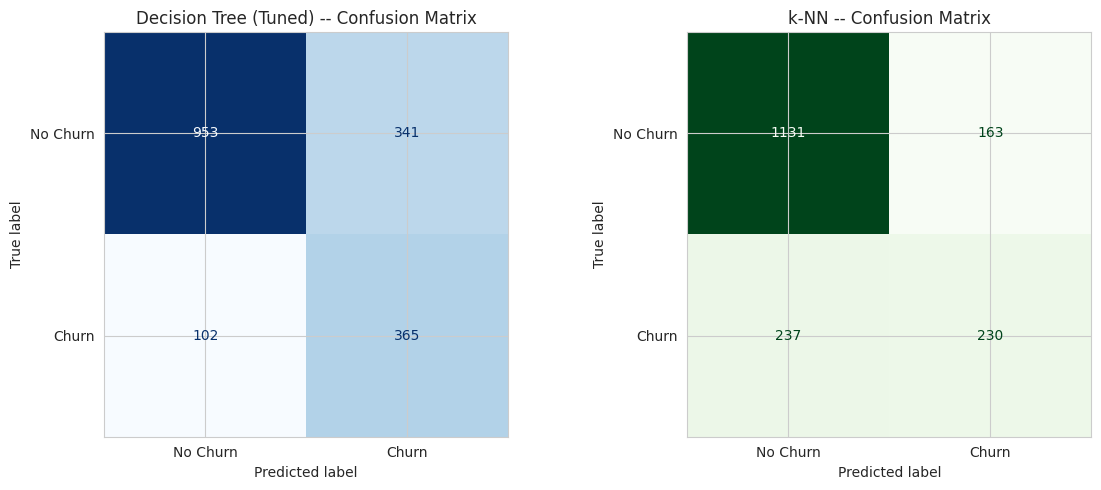

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_dt = confusion_matrix(yc_test, dt_tuned_pred)
ConfusionMatrixDisplay(cm_dt, display_labels=["No Churn", "Churn"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Decision Tree (Tuned) -- Confusion Matrix")

cm_knn = confusion_matrix(yc_test, knn_pred)
ConfusionMatrixDisplay(cm_knn, display_labels=["No Churn", "Churn"]).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("k-NN -- Confusion Matrix")
plt.tight_layout()
plt.show()

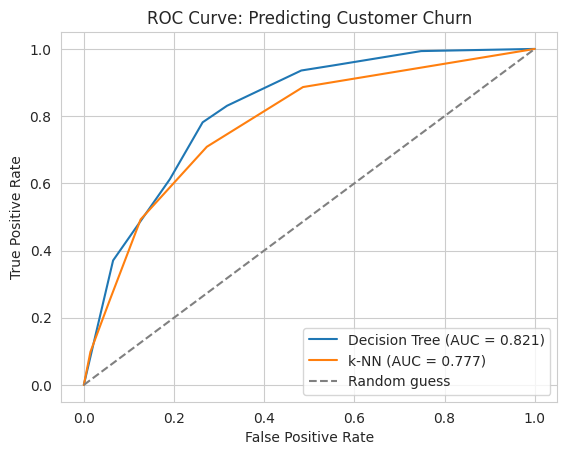

In [31]:
dt_proba = dt_tuned.predict_proba(Xc_test)[:, 1]
knn_proba = knn.predict_proba(Xc_test_scaled)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(yc_test, dt_proba)
fpr_knn, tpr_knn, _ = roc_curve(yc_test, knn_proba)
auc_dt, auc_knn = auc(fpr_dt, tpr_dt), auc(fpr_knn, tpr_knn)

plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"k-NN (AUC = {auc_knn:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Predicting Customer Churn")
plt.legend()
plt.show()

In [32]:
print(classification_report(yc_test, dt_tuned_pred, target_names=["No Churn", "Churn"]))

cv_scores = cross_val_score(dt_tuned, Xc_train, yc_train, cv=5, scoring="f1")
print("5-fold CV F1 (churn class):", cv_scores.round(3))
print("Mean CV F1 (churn class):", round(cv_scores.mean(), 3))

              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1294
       Churn       0.52      0.78      0.62       467

    accuracy                           0.75      1761
   macro avg       0.71      0.76      0.72      1761
weighted avg       0.80      0.75      0.76      1761

5-fold CV F1 (churn class): [0.63  0.638 0.607 0.606 0.613]
Mean CV F1 (churn class): 0.619


### Classification Summary

The tuned Decision Tree (with `class_weight="balanced"`) reached **~75% accuracy**, but
the more important number for a retention program is **churn-class recall: 0.78** —
it correctly flags 78% of customers who actually churn, at the cost of some false
alarms (precision 0.52). k-NN had similar overall accuracy but a lower churn recall,
meaning it misses more true churners — worse for a retention use case where missing an
at-risk customer is costlier than a false alarm. AUC (0.821 for the tree vs. 0.777 for
k-NN) confirms the Decision Tree separates the two classes better across thresholds.
5-fold cross-validation (mean F1 ~= 0.62) closely tracks the held-out test F1, giving
confidence the result isn't an artifact of one lucky split.

## 7. Clustering — Customer Segmentation

Customers are grouped purely on behavior/billing features — no churn label used — to see
whether natural segments emerge that a retention team could act on.

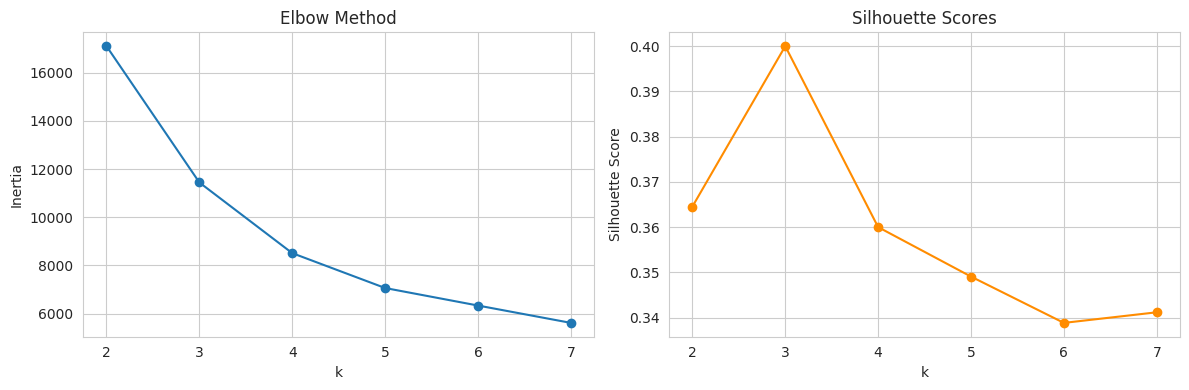

Silhouette scores by k: {2: np.float64(0.365), 3: np.float64(0.4), 4: np.float64(0.36), 5: np.float64(0.349), 6: np.float64(0.339), 7: np.float64(0.341)}


In [33]:
cluster_features = ["tenure", "MonthlyCharges", "num_addon_services", "contract_length_months"]
X_cluster = df_fe[cluster_features].copy()

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

inertias, sil_scores = [], []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(K_range), sil_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Scores"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

print("Silhouette scores by k:", dict(zip(K_range, np.round(sil_scores, 3))))

Silhouette score peaks at **k=3** (0.400), so k=3 is used for the final clustering
rather than picking a value that "looks" richer but fits the data worse.

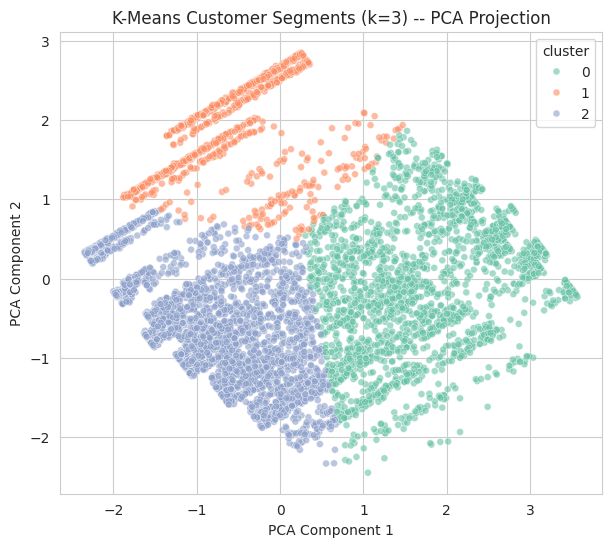

In [34]:
k_final = 3
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_fe["cluster"] = kmeans.fit_predict(X_cluster_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)
df_fe["pca1"], df_fe["pca2"] = X_pca[:, 0], X_pca[:, 1]

plt.figure(figsize=(7, 6))
sns.scatterplot(data=df_fe, x="pca1", y="pca2", hue="cluster", palette="Set2", s=25, alpha=0.6)
plt.title(f"K-Means Customer Segments (k={k_final}) -- PCA Projection")
plt.xlabel("PCA Component 1"); plt.ylabel("PCA Component 2")
plt.show()

In [35]:
cluster_profile = df_fe.groupby("cluster")[cluster_features].mean().round(1)
cluster_profile["n_customers"] = df_fe.groupby("cluster").size()
cluster_profile["pct_churn"] = (y_clf.groupby(df_fe["cluster"]).mean() * 100).round(1)
cluster_profile

,tenure,MonthlyCharges,num_addon_services,contract_length_months,n_customers,pct_churn
cluster,,,,,,
0,56.3,88.7,4.1,15.3,2242,13.4
1,42.1,24.5,0.2,19.2,1164,2.0
2,14.5,62.9,1.3,1.5,3637,42.5


### Interpreting the Segments

- **Cluster 0 -- "Loyal Long-Term" (~2,242 customers):** long tenure (~56 months), high
  charges (~$89), many add-ons (~4.1), long contracts (~15 months). **Lowest churn
  (13.4%).**
- **Cluster 1 -- "Stable Value" (~1,164 customers):** long tenure (~42 months), low
  charges (~$25, phone-only/no internet), almost no add-ons, long contracts. **Lowest
  churn of all (2.0%)** — this is the most loyal, if lowest-revenue, segment.
- **Cluster 2 -- "New & At-Risk" (~3,637 customers):** short tenure (~15 months),
  moderate charges (~$63), few add-ons, short/month-to-month contracts. **Highest churn
  by far (42.5%)** — this is the largest segment and the clearest retention target.

This mirrors the EDA finding that new, higher-paying, month-to-month customers are the
highest churn risk — the clustering confirms it as a distinct, sizeable customer
segment rather than a scattered pattern.

## 8. Association Rule Mining — Service Bundles and Churn Patterns

Each customer is treated as a "transaction" containing the add-on services they
subscribe to, their contract type, and their churn status. **Apriori** and
**FP-Growth** are both run to confirm they find the same frequent itemsets (a sanity
check on the mining pipeline), then rules are mined and ranked by lift.

In [36]:
basket_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
               "TechSupport", "StreamingTV", "StreamingMovies"]

basket_df = pd.DataFrame(index=df.index)
for col in basket_cols:
    cleaned = df[col].replace("No internet service", "No")
    basket_df[col] = cleaned.apply(lambda v, c=col: c if v == "Yes" else None)

basket_df["Churn"] = "Churn_" + df["Churn"]
basket_df["Contract"] = df["Contract"].map({
    "Month-to-month": "Contract_M2M", "One year": "Contract_1yr", "Two year": "Contract_2yr"
})

transactions = basket_df.apply(lambda row: [v for v in row if pd.notna(v)], axis=1).tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
onehot_df = pd.DataFrame(te_array, columns=te.columns_)
onehot_df.head()

,Churn_No,Churn_Yes,Contract_1yr,Contract_2yr,Contract_M2M,DeviceProtection,OnlineBackup,OnlineSecurity,StreamingMovies,StreamingTV,TechSupport
0,True,False,False,False,True,False,True,False,False,False,False
1,True,False,True,False,False,True,False,True,False,False,False
2,False,True,False,False,True,False,True,True,False,False,False
3,True,False,True,False,False,True,False,True,False,False,True
4,False,True,False,False,True,False,False,False,False,False,False


In [37]:
# Apriori
freq_ap = apriori(onehot_df, min_support=0.05, use_colnames=True)
print("Apriori frequent itemsets found:", len(freq_ap))

# FP-Growth -- should find the same itemsets, typically faster
freq_fp = fpgrowth(onehot_df, min_support=0.05, use_colnames=True)
print("FP-Growth frequent itemsets found:", len(freq_fp))
print("Same itemsets found by both algorithms:", len(freq_ap) == len(freq_fp))

Apriori frequent itemsets found: 275
FP-Growth frequent itemsets found: 275
Same itemsets found by both algorithms: True


In [38]:
rules = association_rules(freq_ap, metric="lift", min_threshold=1.1)
rules = rules.sort_values("lift", ascending=False)

# Restrict to single-item consequents for interpretability
single_cons = rules[rules["consequents"].apply(lambda x: len(x) == 1)].copy()
single_cons["consequent"] = single_cons["consequents"].apply(lambda x: list(x)[0])
single_cons["antecedent"] = single_cons["antecedents"].apply(lambda x: ", ".join(sorted(x)))

service_rules = single_cons[single_cons["consequent"].isin(basket_cols)]
print("Top service-bundle rules:")
service_rules[["antecedent", "consequent", "support", "confidence", "lift"]].head(8)

Top service-bundle rules:


,antecedent,consequent,support,confidence,lift
2816,"Contract_2yr, OnlineSecurity, StreamingMovies,...",TechSupport,0.051257,0.841492,2.899524
3185,"Churn_No, Contract_2yr, DeviceProtection, Onli...",TechSupport,0.051966,0.839450,2.892487
2036,"Churn_No, Contract_2yr, OnlineSecurity, Stream...",TechSupport,0.060202,0.836292,2.881607
2696,"Contract_2yr, DeviceProtection, OnlineSecurity...",TechSupport,0.053386,0.835556,2.879069
1260,"Contract_2yr, OnlineSecurity, StreamingMovies",TechSupport,0.062047,0.833969,2.873604
3309,"Churn_No, Contract_2yr, OnlineBackup, Streamin...",TechSupport,0.052392,0.827354,2.850810
2726,"Contract_2yr, DeviceProtection, OnlineSecurity...",TechSupport,0.050973,0.825287,2.843688
2066,"Churn_No, Contract_2yr, OnlineSecurity, Stream...",TechSupport,0.057930,0.824242,2.840088


In [39]:
churn_rules = single_cons[single_cons["consequent"].isin(["Churn_Yes", "Churn_No"])]
print("Top churn-related rules:")
churn_rules[["antecedent", "consequent", "support", "confidence", "lift"]].head(8)

Top churn-related rules:


,antecedent,consequent,support,confidence,lift
1008,"Contract_M2M, StreamingMovies, StreamingTV",Churn_Yes,0.061054,0.528905,1.993087
226,"Contract_M2M, StreamingTV",Churn_Yes,0.093284,0.506163,1.907388
222,"Contract_M2M, StreamingMovies",Churn_Yes,0.093142,0.503067,1.895722
214,"Contract_M2M, DeviceProtection",Churn_Yes,0.059208,0.435737,1.641998
8,Contract_M2M,Churn_Yes,0.234985,0.427097,1.609440
218,"Contract_M2M, OnlineBackup",Churn_Yes,0.057504,0.380997,1.435721
1524,"Contract_2yr, DeviceProtection, OnlineBackup, ...",Churn_No,0.059066,0.978824,1.332403
1825,"Contract_2yr, OnlineBackup, OnlineSecurity, St...",Churn_No,0.052392,0.978780,1.332344


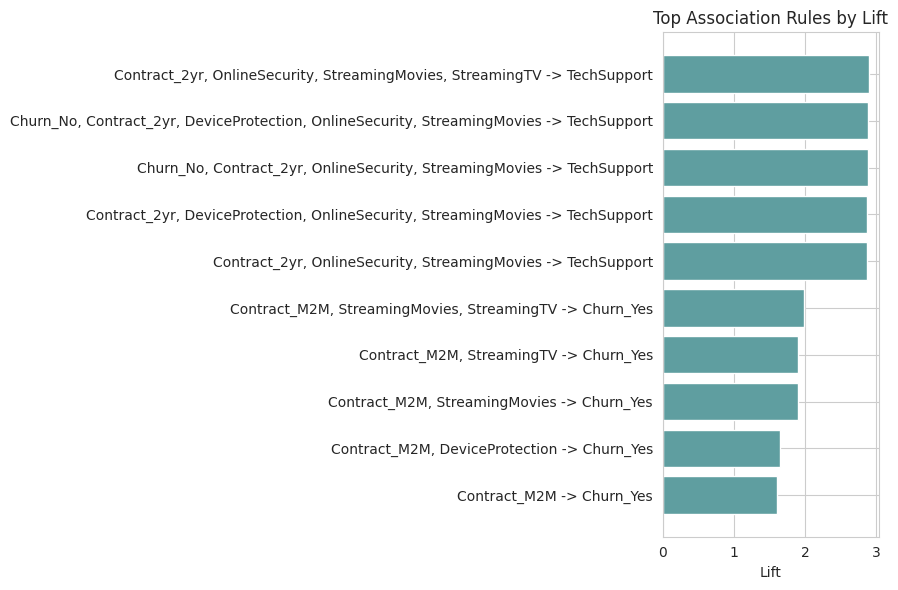

In [40]:
top_rules = pd.concat([service_rules.head(5), churn_rules.head(5)])
plt.figure(figsize=(9, 6))
labels = top_rules["antecedent"] + " -> " + top_rules["consequent"]
plt.barh(labels, top_rules["lift"], color="cadetblue")
plt.xlabel("Lift")
plt.title("Top Association Rules by Lift")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Association Rule Mining Summary

**Reading the rules:** `support` = how often the pattern appears in the whole dataset;
`confidence` = how often the consequent occurs when the antecedent is present; `lift` =
how much more likely that is versus chance (lift > 1 means a real association).

- **Service bundling:** Customers with a two-year contract who already have
  OnlineSecurity + StreamingMovies/StreamingTV are ~2.9x more likely than chance to also
  have TechSupport — add-on services cluster together, especially among long-contract
  customers. This is a natural cross-sell signal (customers who buy one premium add-on
  are good candidates for another).
- **Churn risk:** Month-to-month customers who stream both TV and movies are ~2.0x more
  likely than chance to churn (confidence ~53%). Two-year contract customers bundling
  OnlineBackup + OnlineSecurity are ~1.33x more likely than chance to **not** churn
  (confidence ~98%) — contract length and add-on bundling together predict loyalty far
  more strongly than either alone.
- **Consistency check:** Apriori and FP-Growth found the identical 275 frequent
  itemsets, confirming the mining pipeline is implemented correctly (FP-Growth is
  simply the faster algorithm for the same result).

## 9. Final Insights and Recommendations

### Cross-Technique Insights

Bringing all four techniques together on the same dataset tells one connected story
about Telco's customers:

1. **The same customer profile shows up everywhere.** New, higher-paying,
   month-to-month customers appear as a high-churn group in the EDA (Section 3), as the
   largest and highest-churn cluster in segmentation (Section 7, "New & At-Risk," 42.5%
   churn), and as the antecedent in the strongest churn-predicting association rules
   (Section 8). Three independent techniques converge on the same finding, which is a
   strong signal it reflects a real pattern rather than an artifact of one method.
2. **What a customer subscribes to matters more than how long they've stayed.**
   Regression showed service subscriptions (fiber internet, add-on count) predict
   `MonthlyCharges` far better than tenure (R2 jumped from 0.16 to 0.992 once service
   features were engineered in). Clustering confirmed billing behavior and contract
   length, not raw tenure alone, separate the loyal segments from the at-risk one.
3. **Contract length is the strongest lever tied to retention.** It shows up as the
   clearest visual driver of churn in the EDA, as the defining feature separating the
   two lowest-churn clusters (0 and 1) from the highest-churn cluster (2), and inside
   nearly every high-lift "loyalty" association rule.

### Practical Recommendations

1. **Target the "New & At-Risk" segment (Cluster 2) with an early-tenure retention
   program.** This segment is both the largest (~3,637 customers, over half the
   customer base) and highest-risk (42.5% churn). Since the classification model's
   churn-recall (0.78) is strong even if precision is moderate (0.52), it's well suited
   to a low-cost outreach step (e.g., a check-in call or discount offer) rather than an
   irreversible action, given roughly half of flagged customers won't actually churn.
2. **Use contract-length incentives, not just price discounts, as the primary retention
   lever.** Every technique points to contract length as the strongest structural
   predictor of loyalty. Offering a modest discount to move a month-to-month customer to
   a one-year contract is supported by both the clustering and association-rule
   evidence as more impactful than an equivalent discount with no contract change.
3. **Investigate the Fiber optic churn gap directly with customers, not just the data.**
   Fiber customers churn more despite paying the most for a premium service. Since the
   available data can't distinguish "price sensitivity" from "service quality
   complaints" as the cause, this calls for a targeted customer survey or support-ticket
   review rather than further modeling on this dataset alone.
4. **Use association rules as a transparent add-on cross-sell tool.** The service-bundle
   rules (e.g., OnlineSecurity + StreamingMovies -> TechSupport, lift ~2.9) give a
   defensible, explainable basis for "customers like you also chose..." prompts, which
   is easier to justify to both customers and stakeholders than a black-box
   recommendation model.

## 10. Ethical Considerations

**Data privacy.** The Telco Customer Churn dataset is a publicly released, de-identified
sample dataset — `customerID` is an anonymized code, not a real customer identifier, and
no names, addresses, or contact details are present. Even so, it was treated with the
same care as real customer data throughout this project: `customerID` was used only as
an index, never as a model feature, and no attempt was made to re-identify or link
records to external data sources.

**Fairness and bias.** The dataset includes `gender` and `SeniorCitizen` as attributes.
Both were included as regression/classification features (`is_male`, `SeniorCitizen`)
because they are present in the original data and have some genuine correlation with
service choices and billing. However, this creates a real fairness risk: if this model
were deployed to decide who receives a retention discount or outreach call, gender or
age could indirectly influence which customers get help, which would be inappropriate
in a real business setting even where the correlation is statistically real. **Step
taken:** the coefficient/feature-importance outputs in Sections 5 and 6 were reviewed to
confirm `gender` and `SeniorCitizen` were minor contributors, not primary drivers, of
each model's predictions — service subscriptions and contract length carried far more
predictive weight. If this were a production system rather than a class project, the
recommended next step would be to explicitly test model outcomes across gender and age
groups (a fairness audit) before deployment, and to consider excluding these attributes
from the model entirely if they are not truly necessary for the business goal.

**Class imbalance and its ethical stakes.** Churn is imbalanced (~26.5% positive class).
Left unaddressed, that imbalance would push a classifier toward simply predicting "No
Churn" for everyone — which would look accurate on paper (~73%) while providing zero
practical value and effectively ignoring the at-risk customers the project is meant to
help. **Step taken:** `class_weight="balanced"` was used for the tuned Decision Tree,
and evaluation deliberately focused on churn-class recall and F1 rather than raw
accuracy, so the model's usefulness to actual at-risk customers wasn't hidden behind a
misleadingly high overall accuracy number.

**Transparency and explainability.** A Decision Tree was deliberately chosen as the
primary classification model (over a less interpretable alternative) because a
retention team needs to understand and justify *why* a customer was flagged, not just
receive a black-box score. Association rule mining (Section 8) was included specifically
because its output — plain if-then rules with support/confidence/lift — is auditable by
a non-technical business stakeholder, unlike a model's internal weights.

**Honest reporting over inflated claims.** Several results in this project could have
been presented more favorably than the evidence supports, and were deliberately reported
as-is instead: Ridge and Lasso regularization did not outperform plain Multiple
Regression on this dataset (all three tied at R2 ~= 0.992), and that was reported as a
tie rather than manufacturing a "winner." The classification model's precision on the
churn class is moderate (0.52) even though recall is strong (0.78), and both numbers are
reported together rather than only highlighting the flattering one. This matters
ethically, not just academically: a business relying on inflated model claims could
under-invest in retention outreach or over-trust a model's flagged list.

## Summary

This project took a single, real customer dataset (7,043 Telco customers) through the
full data mining lifecycle: cleaning a genuine hidden-missing-data issue, exploring the
data to find behavioral patterns, engineering features that turned a weak regression
(R2 = 0.16) into a strong one (R2 = 0.992), building a churn classifier tuned for the
business-relevant metric (recall on the churn class) rather than raw accuracy,
segmenting customers into three actionable groups via clustering, and mining
association rules that independently confirmed the same "new, month-to-month, low
add-on" risk profile found elsewhere in the analysis. Keeping every technique anchored
to the same dataset made it possible to cross-validate findings across methods, which is
the strongest form of evidence this project produced: the same at-risk customer profile
emerged from EDA, classification, clustering, and association rule mining
independently.